# Load a forced-turbulence snapshot locally

Loads one snapshot saved by `tests/forced_turbulence_64cubed.py` on the cluster, after you've
downloaded the checkpoint directory to your laptop. Uses `jax_rmhd.snapshot_io.load_snapshot`
directly (imported, not redefined) -- don't paste a local copy of that function into a cell;
an incomplete copy-paste silently returns `None` instead of the loaded state.

In [1]:
import os
os.environ["RMHD_PRECISION"] = "64"
import jax
import jax_rmhd as jr
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import jax_rmhd.snapshot_io as sn
from jax_rmhd import grids
from jax_rmhd.physics import shared_physics

jr.init_cluster()

jax is using 64bit precision.


In [2]:
# These must match the run that produced the snapshots (tests/forced_turbulence_64cubed.py) --
# Parameters() isn't itself saved in the checkpoint, so load_snapshot needs an object with
# matching grid shape / forcing_mode to know what to restore.
nx = ny = nz = 64
Lx = Ly = Lz = 2.0 * jnp.pi

visc = 1e-5
res = 1e-5
hyper = 3

forcing = True
forcing_mode = "elsasser"
forcing_power_elsasser = (0.3, 0.3)
forcing_tau = 1.0
fshell = (1, 3)
forcing_seed = 42
forcing_scale_max = 1.0

# EDIT ME: local path to the snapshot directory you downloaded from the cluster
snap_path = "data/forced_turbulence_64cubed"

params = jr.Parameters(nx=nx, ny=ny, Lx=Lx, Ly=Ly, nz=nz, Lz=Lz, diss=(visc, res),
                        hyper=hyper, cfl_safety=0.5, dims=3,
                        forcing=forcing, forcing_mode=forcing_mode,
                        forcing_power_elsasser=forcing_power_elsasser,
                        forcing_tau=forcing_tau, fshell=fshell, forcing_seed=forcing_seed,
                        forcing_scale_max=forcing_scale_max)

print(f"params.size={params.size} (single-process laptop load -- z-domain is not decomposed)")

kgrid = jr.setup_kgrids(params)

params.size=1 (single-process laptop load -- z-domain is not decomposed)


In [3]:
# get_saved_steps/load_snapshot take the plain snap_path string, not a CheckpointManager --
# there's no need to construct one just to read data back. The cluster run saved with 8 MPI
# ranks, so on disk each rank's real per-step checkpoints live one level down, at
# snap_path/<rank>/<step>/... ; get_saved_steps() handles that layout automatically.
print("Available snapshots:", sorted(sn.get_saved_steps(snap_path)))

Available snapshots: [0, 1, 2, 3, 4]


In [4]:
# EDIT ME: pick a different snapshot index if you want something other than the last one
isnap = max(sn.get_saved_steps(snap_path))
state = sn.load_snapshot(isnap, snap_path, params)
print(f"Loaded snapshot {isnap}: t={float(state.t):.4f}  fields.shape={state.fields.shape}")

Loaded snapshot 4: t=1.1760  fields.shape=(2, 64, 64, 33)


In [5]:
phik, psik = state.fields[0], state.fields[1]
E_kin = 0.5 * float(shared_physics.perp_inner_product(phik, phik, kgrid, params))
E_mag = 0.5 * float(shared_physics.perp_inner_product(psik, psik, kgrid, params))
print(f"E_kin={E_kin:.4e}  E_mag={E_mag:.4e}")

E_kin=1.2093e-01  E_mag=2.0946e-01


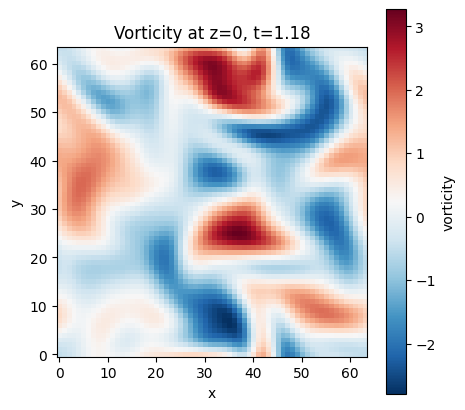

: 

In [ ]:
vort = grids.ifft(-kgrid.ksq() * phik, params)  # (nz, nx, ny), real-space vorticity

plt.figure(figsize=(5, 5))
plt.imshow(np.asarray(vort[0]), origin="lower", cmap="RdBu_r")
plt.colorbar(label="vorticity")
plt.title(f"Vorticity at z=0, t={float(state.t):.2f}")
plt.xlabel("x"); plt.ylabel("y")
plt.show()